In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# print("Path to dataset files:", path)

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

2025-12-12 23:04:54.055713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765580694.457651      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765580694.581764      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [5]:
BASE_PATH = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

In [6]:
NUM_CLASSES = 38
IMG_SIZE_224 = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20 # আপনি চাইলে epochs বাড়াতে বা কমাতে পারেন

print(f"Dataset Train Path: {train_path}")
print(f"Dataset Valid Path: {valid_path}")
print(f"Number of Classes: {NUM_CLASSES}")

Dataset Train Path: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Dataset Valid Path: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Number of Classes: 38


In [7]:
print("\nLoading Training Set...")
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int", 
    image_size=IMG_SIZE_224,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)

total_batches = training_set.cardinality().numpy()
training_set = training_set.shuffle(
    buffer_size=100,
    reshuffle_each_iteration=True
)
portion = 0.5
training_set = training_set.take(int(total_batches * portion))
print(f"Training set loaded, using {int(total_batches * portion)} batches (50%).")

print("Loading Validation Set...")
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE_224,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)
print("Validation set loaded.")


Loading Training Set...
Found 70295 files belonging to 38 classes.


I0000 00:00:1765580752.983801      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765580752.984468      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training set loaded, using 1098 batches (50%).
Loading Validation Set...
Found 17572 files belonging to 38 classes.
Validation set loaded.


In [8]:
base_vgg16 = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE_224 + (3,)
)

base_vgg16.trainable = False

vgg16 = tf.keras.models.Sequential([
    base_vgg16,
    layers.GlobalAveragePooling2D(), 
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
vgg16.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n--- VGG16 Model Summary ---")
vgg16.summary()


--- VGG16 Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,855,782 (56.67 MB)

 Trainable params: 141,094 (551.15 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
print(f"\nStarting training for {EPOCHS} epochs...")
training_history = vgg16.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=EPOCHS
)
print("Training finished.")


Starting training for 20 epochs...
Epoch 1/20


I0000 00:00:1765582118.925002     218 service.cc:148] XLA service 0x7974e00045f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765582118.929845     218 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765582118.929872     218 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765582119.470888     218 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/1098 ━━━━━━━━━━━━━━━━━━━━ 6:33:23 22s/step - accuracy: 0.0312 - loss: 11.2752

I0000 00:00:1765582131.742787     218 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1098/1098 ━━━━━━━━━━━━━━━━━━━━ 302s 256ms/step - accuracy: 0.5643 - loss: 1.9336 - val_accuracy: 0.9001 - val_loss: 0.2985
Epoch 2/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 284s 257ms/step - accuracy: 0.8391 - loss: 0.5016 - val_accuracy: 0.9153 - val_loss: 0.2500
Epoch 3/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 285s 258ms/step - accuracy: 0.8717 - loss: 0.4002 - val_accuracy: 0.9280 - val_loss: 0.2158
Epoch 4/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 285s 257ms/step - accuracy: 0.8854 - loss: 0.3502 - val_accuracy: 0.9251 - val_loss: 0.2141
Epoch 5/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 284s 257ms/step - accuracy: 0.8951 - loss: 0.3188 - val_accuracy: 0.9342 - val_loss: 0.1976
Epoch 6/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 284s 257ms/step - accuracy: 0.8985 - loss: 0.3120 - val_accuracy: 0.9358 - val_loss: 0.1856
Epoch 7/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 285s 257ms/step - accuracy: 0.9028 - loss: 0.2923 - val_accuracy: 0.9380 - val_loss: 0.1836
Epoch 8/20
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 285s 257ms/step - accuracy: 0.9

In [12]:
MODEL_ID = "VGG16"
MODEL_SAVE_PATH = f"{MODEL_ID.lower()}_plant_disease_model.h5" 
try:
    vgg16.save(MODEL_SAVE_PATH)
    print(f"\n Model successfully saved as: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"\nError saving model: {e}")


✅ Model successfully saved as: vgg16_plant_disease_model.h5


In [13]:
train_loss, train_acc = vgg16.evaluate(training_set, verbose=0)
print(f'\nTraining accuracy: {train_acc:.4f}')

val_loss, val_acc = vgg16.evaluate(validation_set, verbose=0)
print(f'Validation accuracy: {val_acc:.4f}')


Training accuracy: 0.9798
Validation accuracy: 0.9525


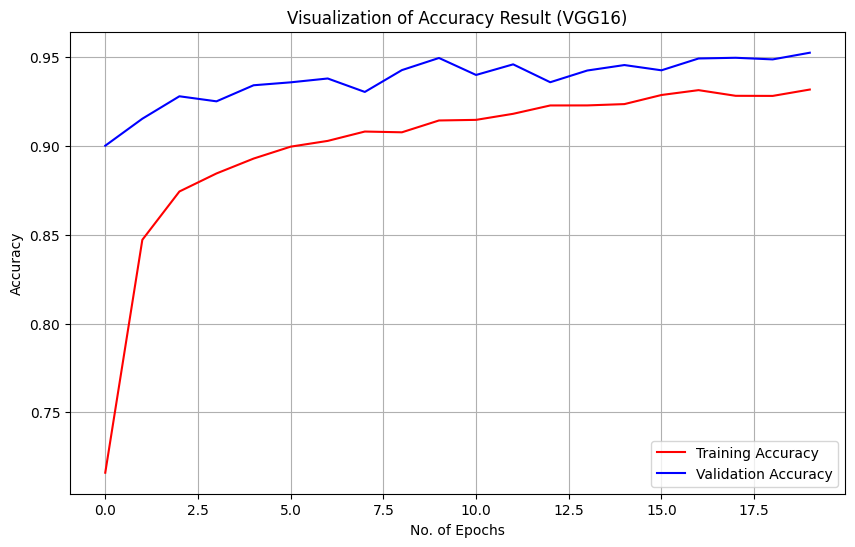

In [14]:
epochs_range = range(EPOCHS)
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs_range, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title('Visualization of Accuracy Result (VGG16)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
class_name = validation_set.class_names
print("\n--- Preparing Test Set for Confusion Matrix ---")


test_set = tf.keras.utils.image_dataset_from_directory(
    valid_path, 
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=1,
    image_size=IMG_SIZE_224,
    shuffle=False,
)


--- Preparing Test Set for Confusion Matrix ---
Found 17572 files belonging to 38 classes.


In [16]:
# প্রেডিকশন তৈরি
print("Generating predictions...")
y_pred = vgg16.predict(test_set, verbose=1)

# সঠিক লেবেল (True Labels) এবং প্রেডিক্টেড লেবেল (Predicted Labels) বের করা
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = true_categories.numpy()
predicted_categories = tf.argmax(y_pred, axis=1).numpy()


Generating predictions...
17572/17572 ━━━━━━━━━━━━━━━━━━━━ 156s 9ms/step


In [17]:
report = classification_report(Y_true, predicted_categories, target_names=class_name, output_dict=True)

print("\n--- Classification Report ---")
print(classification_report(Y_true, predicted_categories, target_names=class_name, digits=4))


--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9915    0.9286    0.9590       504
                                 Apple___Black_rot     0.9719    0.9759    0.9739       497
                          Apple___Cedar_apple_rust     0.9625    0.9909    0.9765       440
                                   Apple___healthy     0.9154    0.9920    0.9522       502
                               Blueberry___healthy     0.9932    0.9692    0.9810       454
          Cherry_(including_sour)___Powdery_mildew     0.9928    0.9881    0.9905       421
                 Cherry_(including_sour)___healthy     0.9934    0.9956    0.9945       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9780    0.8659    0.9185       410
                       Corn_(maize)___Common_rust_     0.9979    0.9937    0.9958       477
               Corn_(maize)___Northern_Leaf_Blig

In [19]:
metrics_summary = {
    'Model': MODEL_ID,
    'Accuracy': report['accuracy'],
    'Precision (Wgt Avg)': report['weighted avg']['precision'], 
    'Recall (Wgt Avg)': report['weighted avg']['recall'],
    'F1-Score (Wgt Avg)': report['weighted avg']['f1-score'],
}

df_metrics = pd.DataFrame([metrics_summary])
results_file = 'model_performance_summary.csv'

In [21]:
import os
if not os.path.exists(results_file):
    df_metrics.to_csv(results_file, index=False)
else:
    df_metrics.to_csv(results_file, mode='a', header=False, index=False)
    
print(f"\n✅ Metrics successfully saved/appended to {results_file}")


✅ Metrics successfully saved/appended to model_performance_summary.csv


In [ ]:
#  কনফিউশন ম্যাট্রিক্স ভিজ্যুয়ালাইজেশন
# cm = confusion_matrix(Y_true, predicted_categories)
# plt.figure(figsize=(40, 40))
# sns.heatmap(cm, annot=True, annot_kws={"size": 10}, fmt='d', cmap='Blues',
#             xticklabels=class_name, yticklabels=class_name)
# plt.xlabel('Predicted Class', fontsize=20)
# plt.ylabel('Actual Class', fontsize=20)
# plt.title('Plant Disease Prediction Confusion Matrix (VGG16)', fontsize=25)
# plt.show()

# print("\n--- Code execution complete ---")